<img src="https://www.metu.edu.tr/system/files/logo_orj/5/5.4.jpg" width="400" alt="Weights & Biases" />

# <font color='RED'>**📄 Surface Roughness Prediction In Additive Manufacturing**</font>

# Introduction

This notebook contains the machine learning workflow using the combined experimental and synthetic dataset. It is provided to examine the effect of synthetic data augmentation on model training and predictive performance.

Key Parameters:

The study focuses on 8 key printing parameters as model inputs ($X$): Layer Height, Extrusion Temperature, Outer Wall Speed, Infill Density, Wall Thickness, Bed Temperature, Fan Speed, and Surface Angle. The target output ($Y$) is the $R_a$ value.

## Please try installing the environment as described in the Readme file. If you want to run the code with your own Python environment, please ensure that the following libraries are installed.

In [ ]:
# pip install matplotlib numpy optuna pandas scikit-learn scipy shap tensorflow

# MLP (Real + Sythetic Data Generated by CGAN)

Random seeds set to: 42
TensorFlow version: 2.19.0
Deterministic operations enabled: True
SECTION 1: DATA LOADING AND PREPROCESSING
Total samples: 1530
Number of features: 8

*** DATA SPLIT ***
Training samples (real):   1070 (69.9%)
Validation samples (real): 230 (15.0%)
Test samples (real):       230 (15.0%)

Data preprocessing completed.
Feature dimension: 8
Latent dimension: 20

SECTION 2: CGAN ARCHITECTURE
Generator Summary:


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_input         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ condition_input     │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28)        │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ condition_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      7,424 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 256)       │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128)       │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ leaky_re_lu_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generator_output    │ (None, 1)         │        129 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 307,969 (1.17 MB)

 Trainable params: 305,665 (1.17 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ra_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ condition_input     │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 9)         │          0 │ ra_input[0][0],   │
│ (Concatenate)       │                   │            │ condition_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │      2,560 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 256)       │          0 │ dense_4[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 128)       │          0 │ dense_5[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 64)        │          0 │ dense_6[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discriminator_outp… │ (None, 1)         │         65 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,777 (171.00 KB)

 Trainable params: 43,777 (171.00 KB)

 Non-trainable params: 0 (0.00 B)


SECTION 3: CGAN TRAINING

Training CGAN for 5000 epochs...
Batch size: 32
CGAN training completed!


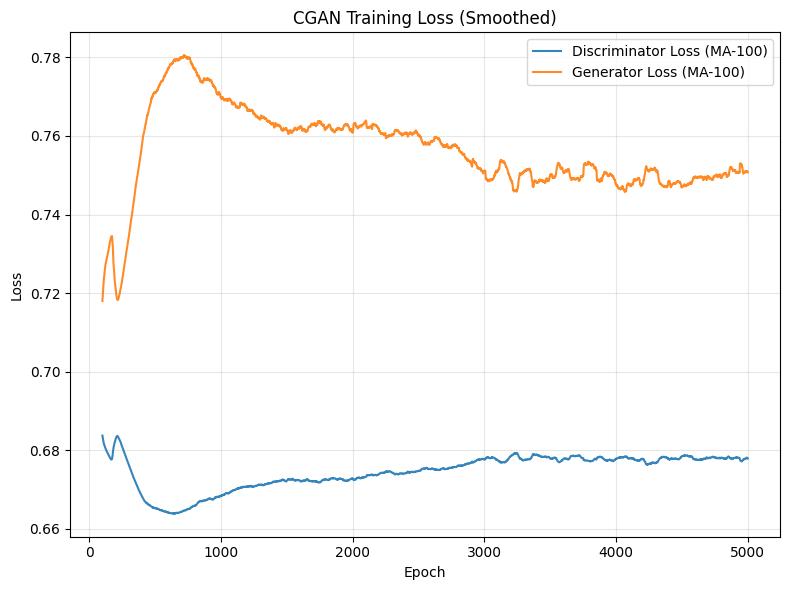


SECTION 4: SYNTHETIC DATA GENERATION

Generating augmented datasets for candidate augmentation ratios...
  Ratio 0.5x: 1605 total samples
  Ratio 1.0x: 2140 total samples
  Ratio 2.0x: 3210 total samples
  Ratio 3.0x: 4280 total samples
  Ratio 4.0x: 5350 total samples
  Ratio 5.0x: 6420 total samples
  Ratio 6.0x: 7490 total samples
  Ratio 7.0x: 8560 total samples
  Ratio 8.0x: 9630 total samples
  Ratio 9.0x: 10700 total samples
  Ratio 10.0x: 11770 total samples

SECTION 5: MLP MODEL DEFINITION
MLP Regressor Architecture:


Model: "MLP_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leakyrelu_0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leakyrelu_1 (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 224)            │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leakyrelu_2 (LeakyReLU)         │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 352)            │        79,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leakyrelu_3 (LeakyReLU)         │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 224)            │        79,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leakyrelu_4 (LeakyReLU)         │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,545 (658.38 KB)

 Trainable params: 168,545 (658.38 KB)

 Non-trainable params: 0 (0.00 B)


SECTION 6: COMPARATIVE EVALUATION

Model selection criterion: Lowest validation MAE. Test set is used only for final reporting.


SECTION 7: RESULTS SUMMARY

PERFORMANCE COMPARISON — MODEL SELECTION BASED ON VALIDATION MAE
Model                        VAL_MAE     VAL_R²   VAL_MAPE      VAL_MSE |   TEST_MAE    TEST_R²  TEST_MAPE     TEST_MSE
--------------------------------------------------------------------------------------------------------------------------
MLP (Real Only)                2.230      0.844      0.126       12.549 |      1.964      0.860      0.118        9.656
MLP (Aug 0.5x)                 1.990      0.875      0.115       10.057 |      1.952      0.872      0.117        8.861
MLP (Aug 1.0x)                 1.926      0.870      0.113       10.448 |      1.840      0.896      0.112        7.162
MLP (Aug 2.0x)                 2.201      0.859      0.128       11.363 |      1.934      0.886      0.119        7.877
MLP (Aug 3.0x)                 1.773      0.894      

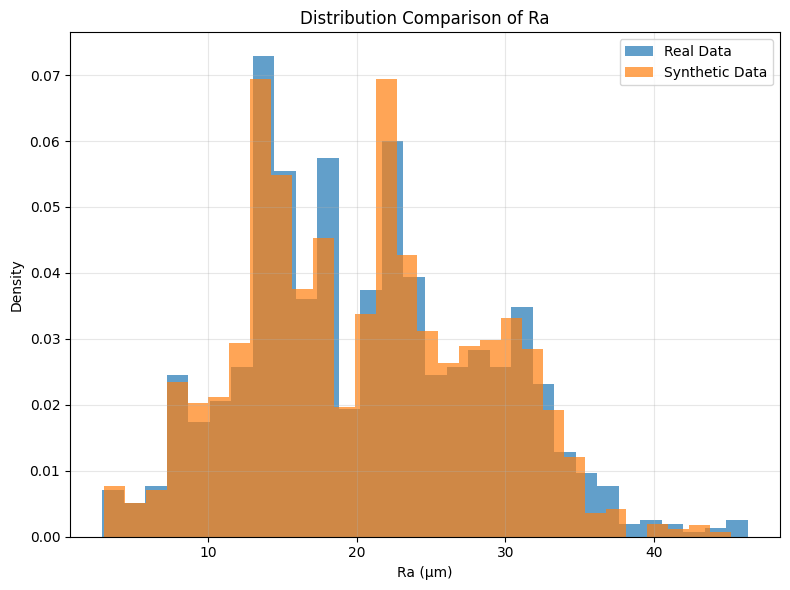

C:\Users\ederkan\AppData\Local\Temp\ipykernel_23708\3994729653.py:550: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_train_real, y_syn_best], labels=["Real Data", "Synthetic Data"], patch_artist=True)


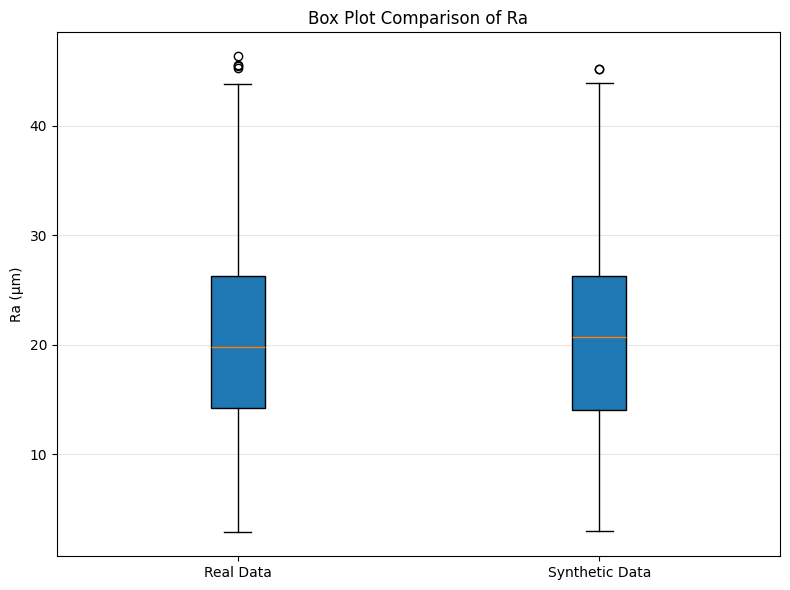


SECTION 9: VISUALIZATIONS


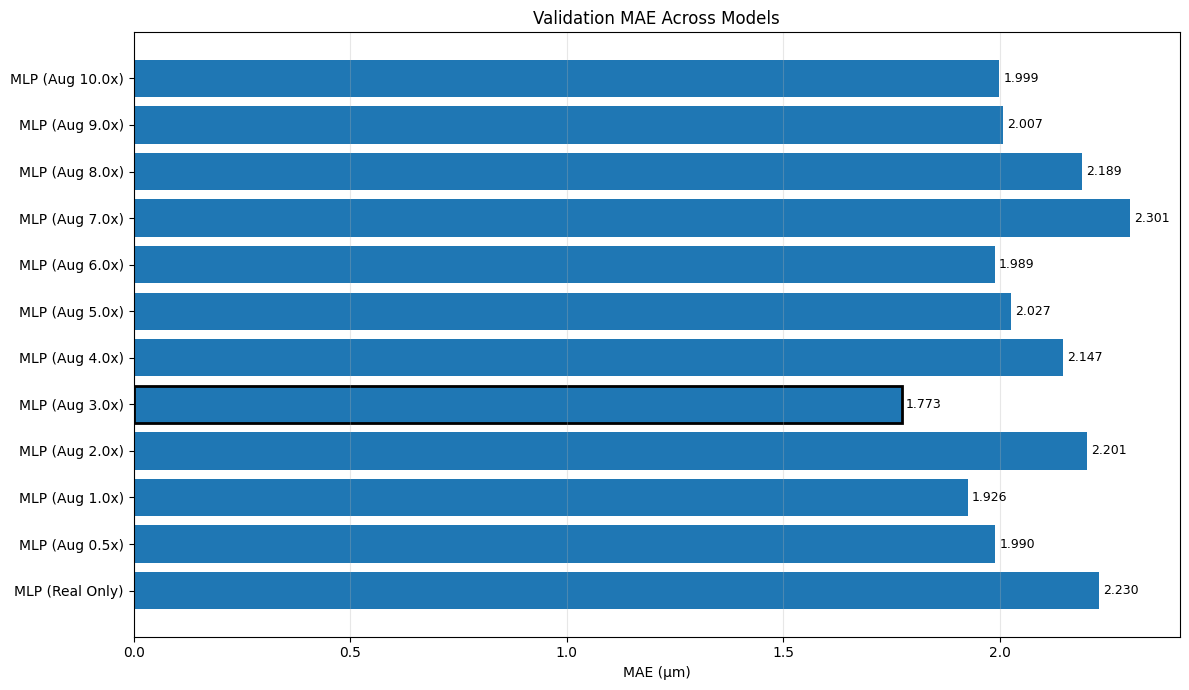

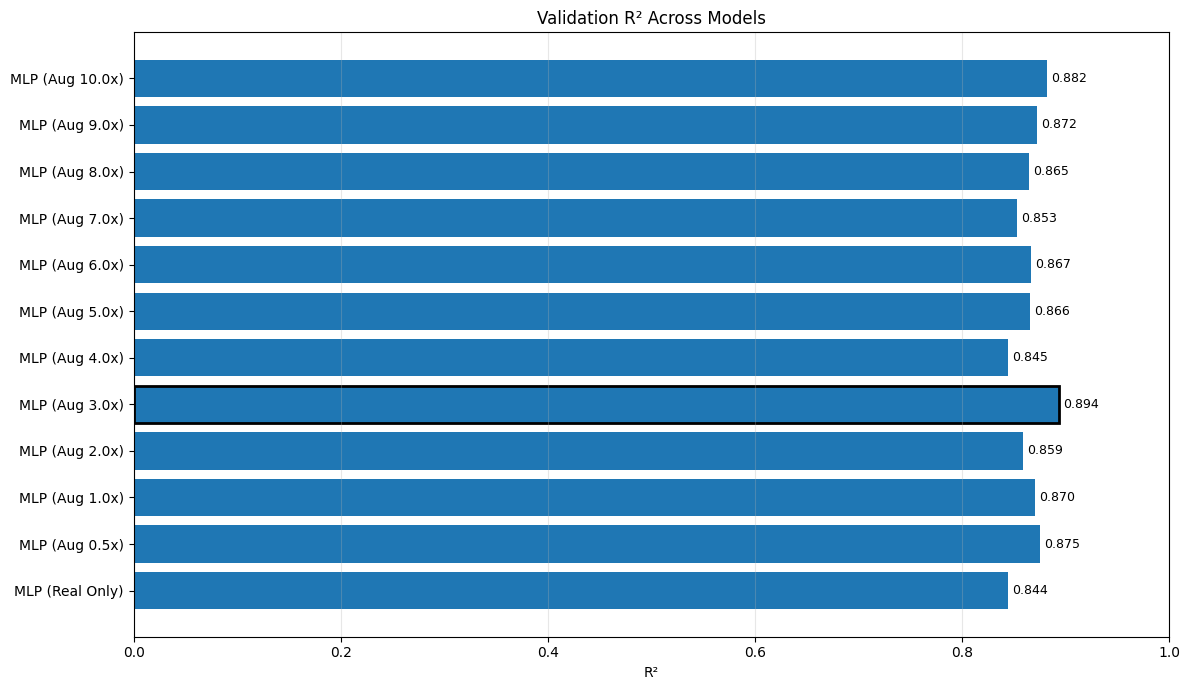

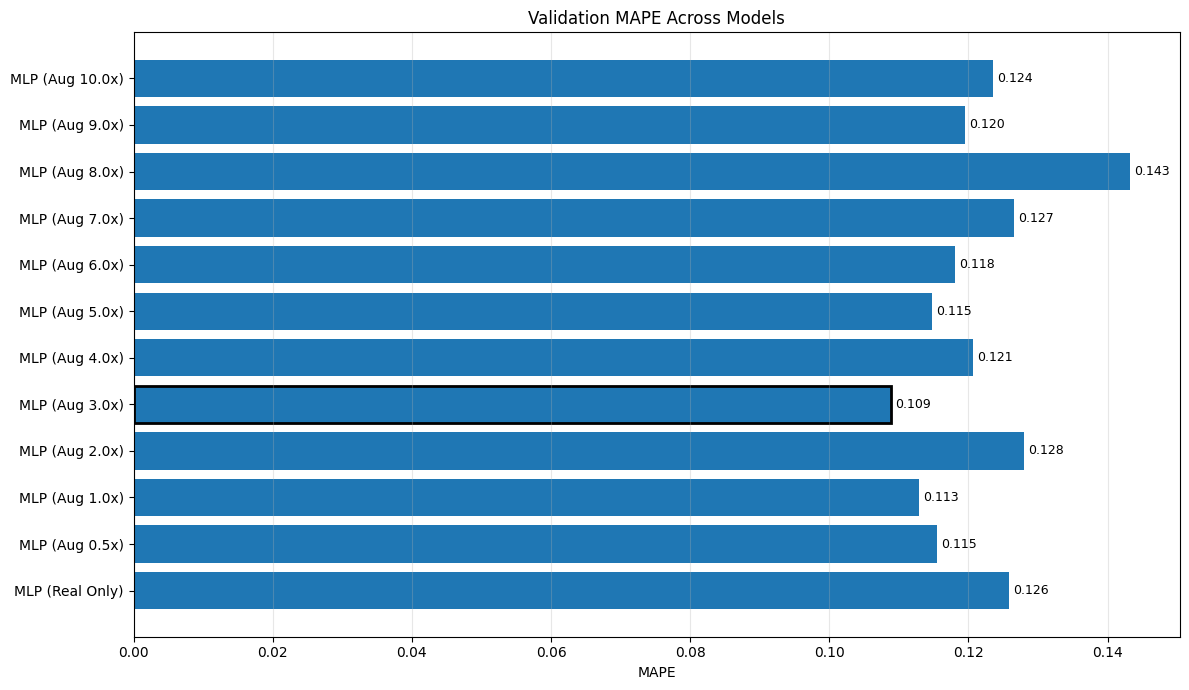

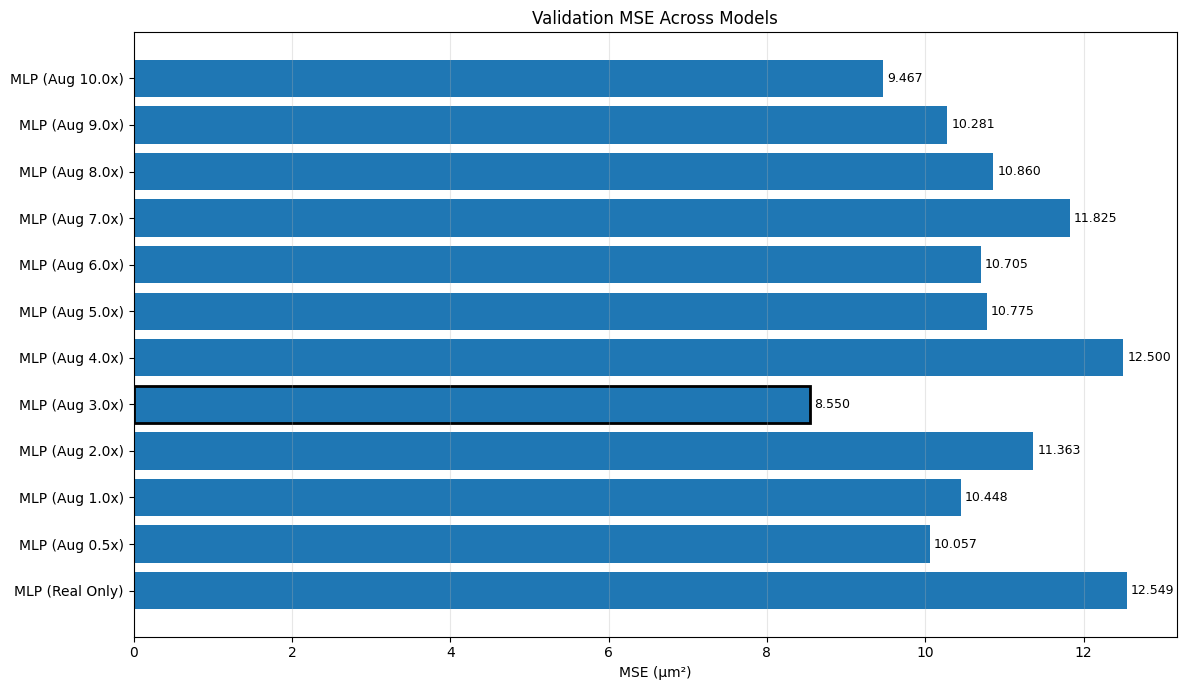

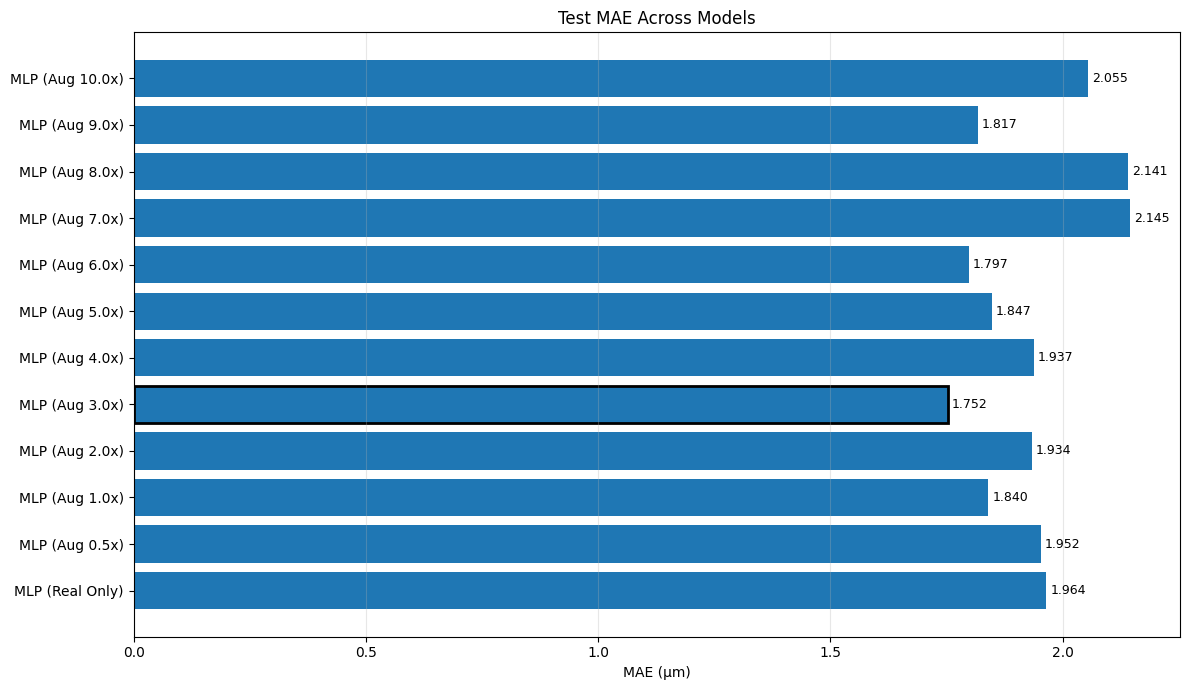

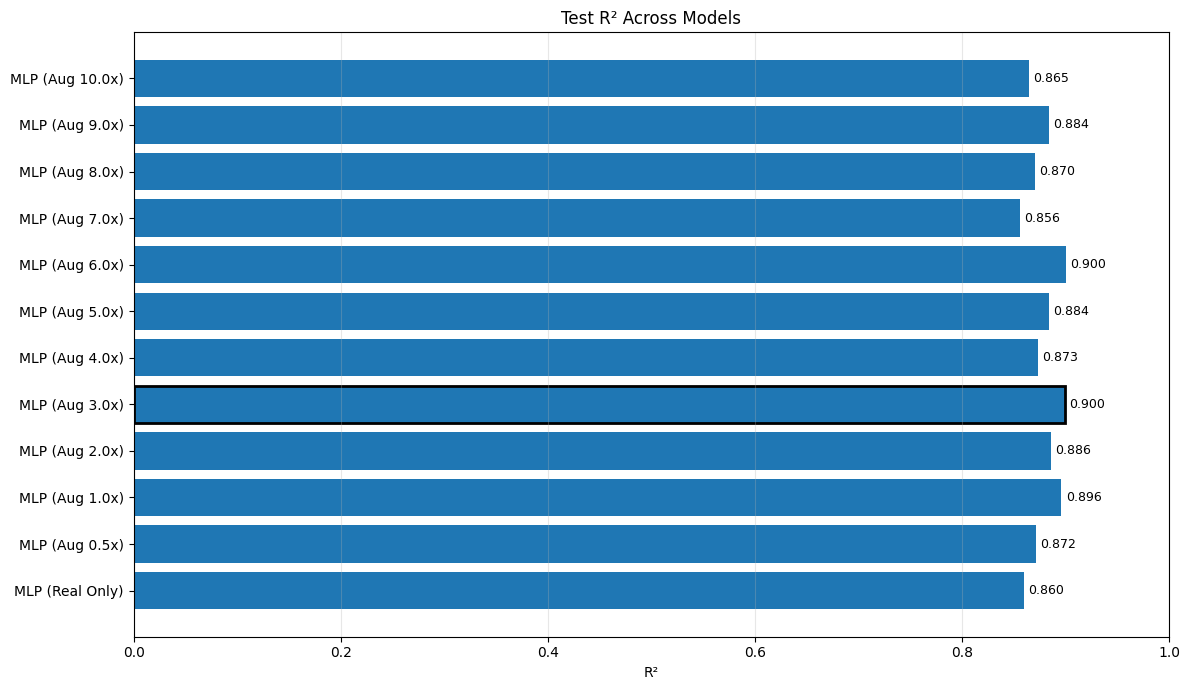

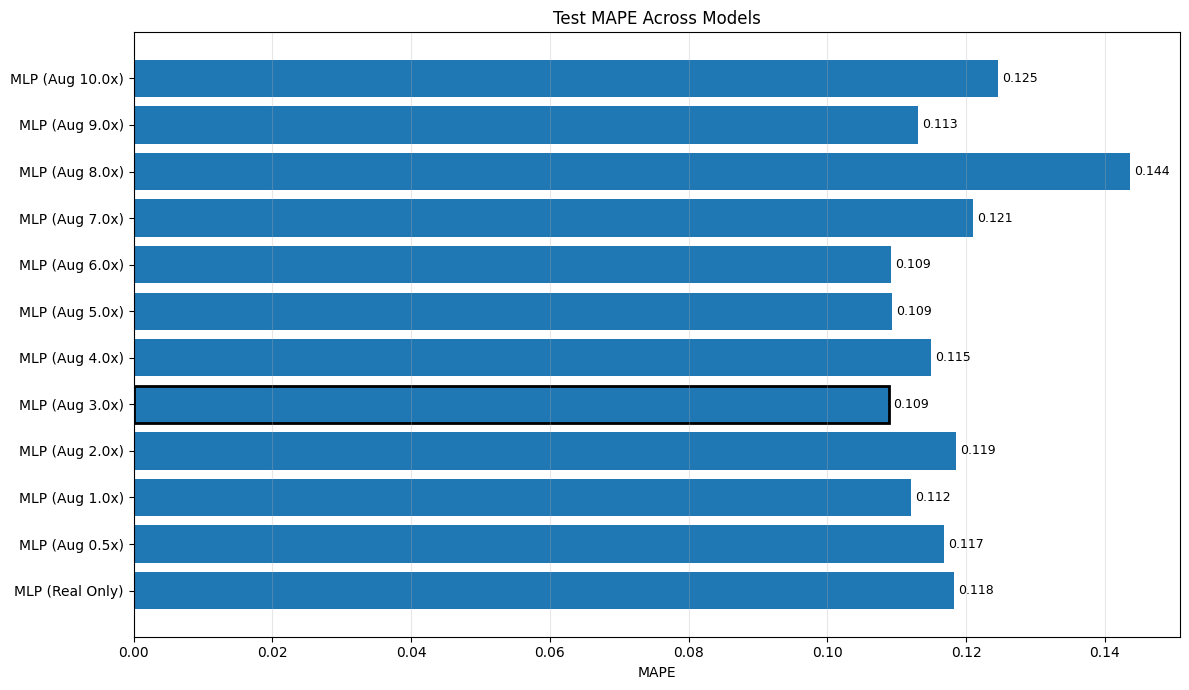

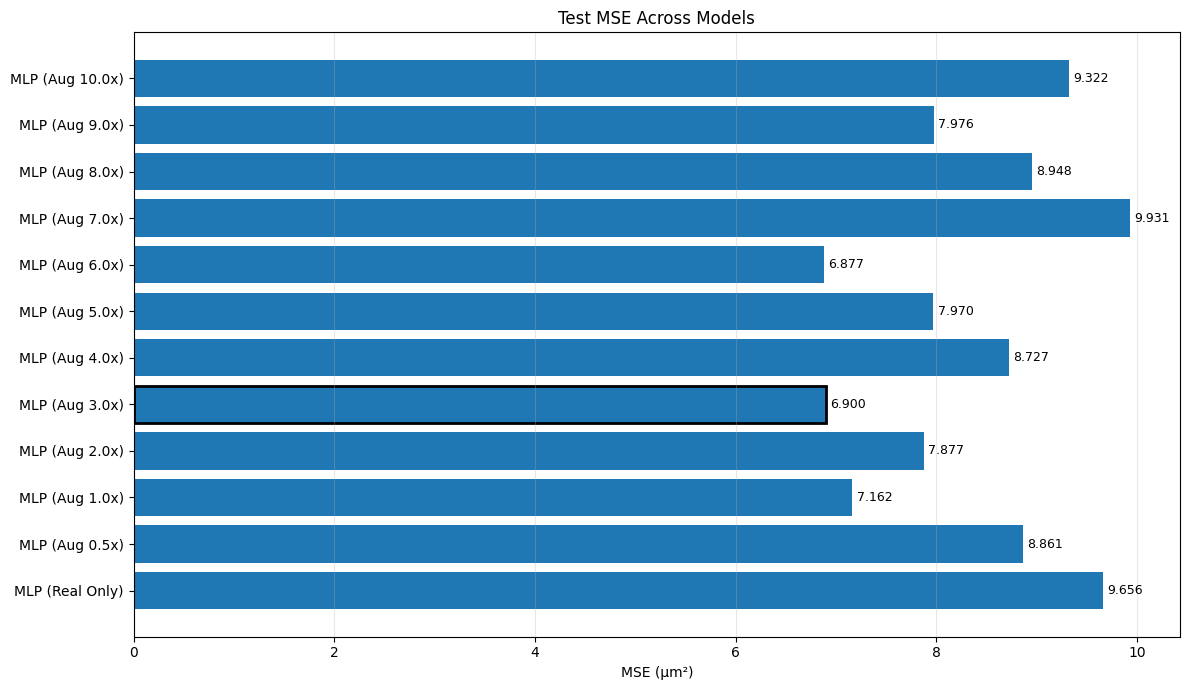

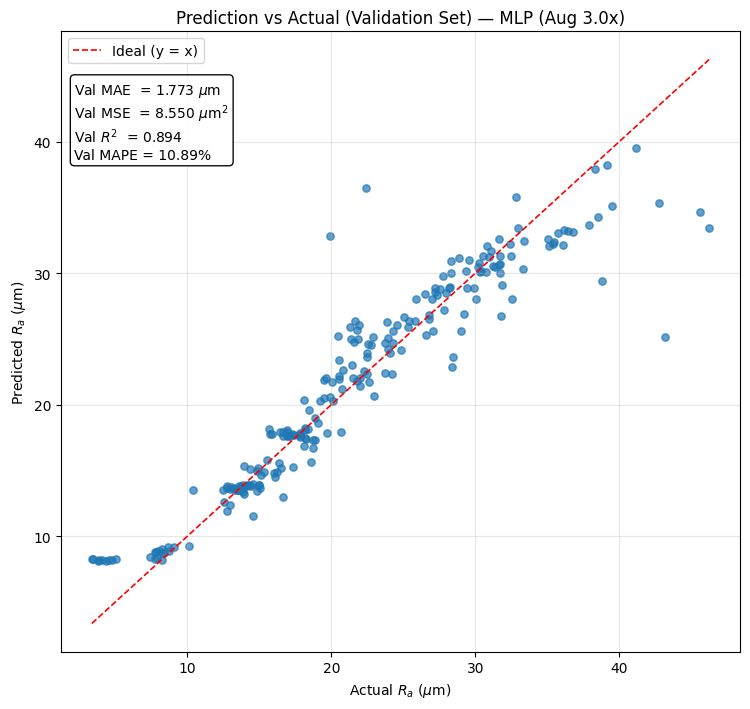

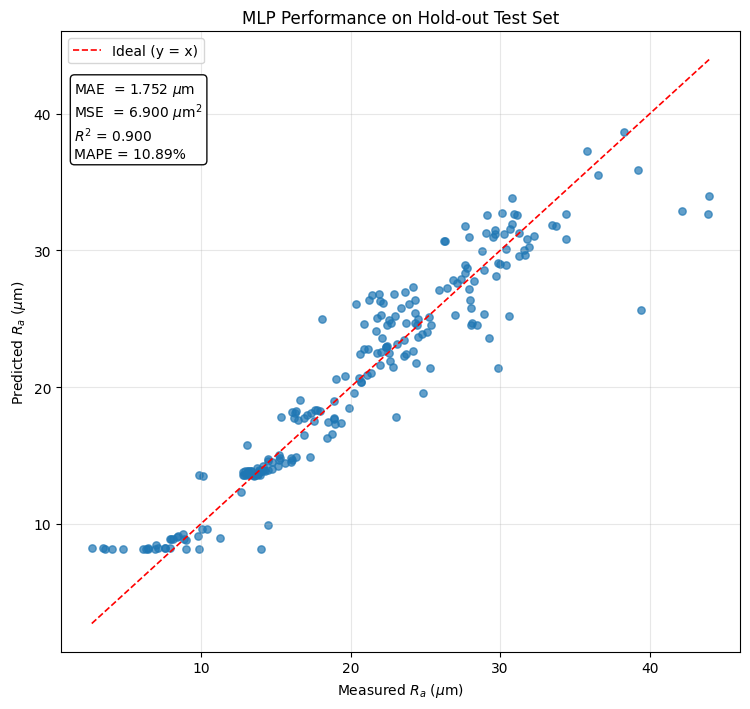


SECTION 10: EXPORTING RESULTS AND SAVING MODELS
Best model info dictionary created but NOT saved (SAVE_FILES=False).


In [ ]:
import os
import random

# ==============================================================================
# Reproducibility and Determinism Configuration
# ==============================================================================
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    mean_squared_error,
)
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print(f"Random seeds set to: {SEED}")
print(f"TensorFlow version: {tf.__version__}")
print("Deterministic operations enabled: True")

# CGAN hyperparameters
CGAN_LATENT_DIM = 20
CGAN_LR = 0.0002
CGAN_BATCH_SIZE = 32
CGAN_EPOCHS = 5000

# Synthetic data generation parameters
SYNTHETIC_SAMPLE_WEIGHT = 0.30
JITTER_STD_SCALED = 0.005

# MLP tuned hyperparameters
MLP_N_LAYERS = 5
MLP_UNITS = [64, 32, 224, 352, 224]
MLP_DROPOUT = 0.3
MLP_ACTIVATION = "leaky_relu"  
MLP_LEAKY_SLOPE = 0.1        
MLP_LR = 0.005
MLP_L2 = 0.0
MLP_BATCH_SIZE = 64
MLP_EPOCHS = 500

# Model selection criterion
SELECTION_METRIC = "VAL_MAE"    # validation-based selection

# ==============================================================================
# SECTION 1: Data Loading and Preprocessing
# ==============================================================================
print("=" * 70)
print("SECTION 1: DATA LOADING AND PREPROCESSING")
print("=" * 70)

DATA_PATH = Path("..") / "dataset" / "surface_roughness_data.csv"
df = pd.read_csv(DATA_PATH)

# Objects 85, 86, and 87 correspond to identical Box-Behnken center-point settings.
# To avoid repeated center-point samples in the analysis, only Object-85 is retained.
df = df[~df["ID"].isin(["Object-86", "Object-87"])].copy()

input_cols = [
    "Layer Height (mm)", "Extrusion Temp (°C)", "Outer Wall Speed (mm/s)",
    "Infill Density (%)", "Wall Thickness (mm)", "Bed Temp (°C)",
    "Fan Speed (%)", "Surface Angle (°)"
]
output_col = ["Ra"]

X_raw = df[input_cols].values
y_raw = df[output_col].values

print(f"Total samples: {len(X_raw)}")
print(f"Number of features: {len(input_cols)}")

# ==============================================================================
# Data Split: 70% Train, 15% Validation, 15% Test
# ==============================================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=SEED
)

X_train_real, X_val, y_train_real, y_val = train_test_split(
    X_temp, y_temp, test_size=15/85, random_state=SEED
)

y_train_real = y_train_real.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

print("\n*** DATA SPLIT ***")
print(f"Training samples (real):   {len(X_train_real)} ({len(X_train_real)/len(X_raw)*100:.1f}%)")
print(f"Validation samples (real): {len(X_val)} ({len(X_val)/len(X_raw)*100:.1f}%)")
print(f"Test samples (real):       {len(X_test)} ({len(X_test)/len(X_raw)*100:.1f}%)")

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train_real)
y_train_scaled = scaler_y.fit_transform(y_train_real.reshape(-1, 1))

X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

num_features = X_train_scaled.shape[1]
latent_dim = CGAN_LATENT_DIM

print("\nData preprocessing completed.")
print(f"Feature dimension: {num_features}")
print(f"Latent dimension: {latent_dim}")

# ==============================================================================
# SECTION 2: CGAN Architecture
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 2: CGAN ARCHITECTURE")
print("=" * 70)

def build_generator(latent_dim, num_features):
    noise_input = Input(shape=(latent_dim,), name="noise_input")
    condition_input = Input(shape=(num_features,), name="condition_input")
    x = layers.Concatenate()([noise_input, condition_input])

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization()(x)

    output = layers.Dense(1, activation="sigmoid", name="generator_output")(x)
    return models.Model([noise_input, condition_input], output, name="Generator")


def build_discriminator(num_features):
    ra_input = Input(shape=(1,), name="ra_input")
    condition_input = Input(shape=(num_features,), name="condition_input")
    x = layers.Concatenate()([ra_input, condition_input])

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, activation="sigmoid", name="discriminator_output")(x)
    return models.Model([ra_input, condition_input], output, name="Discriminator")


class ConditionalGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = tf.keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, data):
        real_conditions, real_targets = data
        batch_size = tf.shape(real_conditions)[0]

        # Discriminator
        z = tf.random.normal(shape=(batch_size, self.latent_dim))
        fake_targets = self.generator([z, real_conditions])

        labels_real = tf.ones((batch_size, 1)) * 0.9
        labels_fake = tf.zeros((batch_size, 1)) + 0.1

        with tf.GradientTape() as tape:
            pred_real = self.discriminator([real_targets, real_conditions])
            pred_fake = self.discriminator([fake_targets, real_conditions])
            d_loss_real = self.loss_fn(labels_real, pred_real)
            d_loss_fake = self.loss_fn(labels_fake, pred_fake)
            d_loss = (d_loss_real + d_loss_fake) / 2.0

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # Generator
        z = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_targets = self.generator([z, real_conditions])
            pred = self.discriminator([fake_targets, real_conditions])
            g_loss = self.loss_fn(misleading_labels, pred)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}


generator = build_generator(latent_dim, num_features)
discriminator = build_discriminator(num_features)

print("Generator Summary:")
generator.summary()
print("\nDiscriminator Summary:")
discriminator.summary()

# ==============================================================================
# SECTION 3: CGAN Training
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 3: CGAN TRAINING")
print("=" * 70)

cgan = ConditionalGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
cgan.compile(
    d_optimizer=tf.keras.optimizers.Adam(learning_rate=CGAN_LR, beta_1=0.5),
    g_optimizer=tf.keras.optimizers.Adam(learning_rate=CGAN_LR, beta_1=0.5),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=False),
)

print(f"\nTraining CGAN for {CGAN_EPOCHS} epochs...")
print(f"Batch size: {CGAN_BATCH_SIZE}")

history = cgan.fit(
    x=X_train_scaled,
    y=y_train_scaled,
    batch_size=CGAN_BATCH_SIZE,
    epochs=CGAN_EPOCHS,
    verbose=0,
)

print("CGAN training completed!")

plt.figure(figsize=(8, 6))
window = 100
d_loss_smooth = pd.Series(history.history["d_loss"]).rolling(window).mean()
g_loss_smooth = pd.Series(history.history["g_loss"]).rolling(window).mean()
plt.plot(d_loss_smooth, label=f"Discriminator Loss (MA-{window})", alpha=0.9)
plt.plot(g_loss_smooth, label=f"Generator Loss (MA-{window})", alpha=0.9)
plt.title("CGAN Training Loss (Smoothed)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 4: Synthetic Data Generation
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 4: SYNTHETIC DATA GENERATION")
print("=" * 70)

def create_augmented_dataset(
    X_train_real,
    y_train_real,
    X_train_scaled,
    generator,
    scaler_x,
    scaler_y,
    latent_dim,
    augmentation_ratio=1.0,
    synthetic_weight=0.30,
    jitter_std_scaled=0.003,
):
    n_real = len(X_train_real)
    n_synthetic = int(n_real * augmentation_ratio)

    indices = np.random.choice(n_real, n_synthetic, replace=True)
    base_conditions = X_train_scaled[indices].copy()

    jitter = np.random.normal(loc=0.0, scale=jitter_std_scaled, size=base_conditions.shape).astype(np.float32)
    conditions_jittered = np.clip(base_conditions + jitter, 0.0, 1.0)

    noise = np.random.normal(0, 1, (n_synthetic, latent_dim)).astype(np.float32)
    synthetic_ra_scaled = generator.predict([noise, conditions_jittered], verbose=0)
    synthetic_ra = scaler_y.inverse_transform(synthetic_ra_scaled).flatten()

    synthetic_X = scaler_x.inverse_transform(conditions_jittered)

    X_augmented = np.vstack([X_train_real, synthetic_X])
    y_augmented = np.concatenate([y_train_real, synthetic_ra])

    w_real = np.ones(n_real, dtype=np.float32)
    w_syn = np.ones(n_synthetic, dtype=np.float32) * float(synthetic_weight)
    sample_weight = np.concatenate([w_real, w_syn]).astype(np.float32)

    return X_augmented, y_augmented, sample_weight


augmentation_ratios = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

print("\nGenerating augmented datasets for candidate augmentation ratios...")
augmented_datasets = {}
for ratio in augmentation_ratios:
    X_aug, y_aug, w_aug = create_augmented_dataset(
        X_train_real,
        y_train_real,
        X_train_scaled,
        generator,
        scaler_x,
        scaler_y,
        latent_dim,
        augmentation_ratio=ratio,
        synthetic_weight=SYNTHETIC_SAMPLE_WEIGHT,
        jitter_std_scaled=JITTER_STD_SCALED,
    )
    augmented_datasets[ratio] = (X_aug, y_aug, w_aug)
    print(f"  Ratio {ratio}x: {len(X_aug)} total samples")

# ==============================================================================
# SECTION 5: MLP Model Definition
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 5: MLP MODEL DEFINITION")
print("=" * 70)

def build_mlp_regressor(input_dim):
    model = models.Sequential(name="MLP_Regressor")
    model.add(Input(shape=(input_dim,)))

    for i in range(MLP_N_LAYERS):
        model.add(
            layers.Dense(
                MLP_UNITS[i],
                activation=None if MLP_ACTIVATION == "leaky_relu" else MLP_ACTIVATION,
                kernel_regularizer=regularizers.l2(MLP_L2),
                name=f"dense_{i}",
            )
        )
        if MLP_ACTIVATION == "leaky_relu":
            model.add(layers.LeakyReLU(negative_slope=MLP_LEAKY_SLOPE, name=f"leakyrelu_{i}"))
        model.add(layers.Dropout(MLP_DROPOUT, name=f"dropout_{i}"))

    model.add(layers.Dense(1, activation="linear", name="output"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=MLP_LR),
        loss="mse",
        metrics=["mae"],
    )
    return model


def train_and_evaluate_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    scaler_x,
    sample_weight=None,
    epochs=MLP_EPOCHS,
    batch_size=MLP_BATCH_SIZE,
    verbose=0,
):
    X_train_s = scaler_x.transform(X_train)
    X_val_s = scaler_x.transform(X_val)
    X_test_s = scaler_x.transform(X_test)

    model = build_mlp_regressor(input_dim=X_train_s.shape[1])

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=20, min_lr=1e-6, verbose=0),
    ]

    history = model.fit(
        X_train_s,
        y_train,
        validation_data=(X_val_s, y_val),
        sample_weight=sample_weight,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )

    # Validation metrics
    y_val_pred = model.predict(X_val_s, verbose=0).flatten()
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    val_mape = mean_absolute_percentage_error(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)

    # Test metrics
    y_test_pred = model.predict(X_test_s, verbose=0).flatten()
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    return {
        "model": model,
        "history": history,
        "val_pred": y_val_pred,
        "test_pred": y_test_pred,
        "VAL_MAE": val_mae,
        "VAL_R2": val_r2,
        "VAL_MAPE": val_mape,
        "VAL_MSE": val_mse,
        "MAE": test_mae,
        "R2": test_r2,
        "MAPE": test_mape,
        "MSE": test_mse,
        "epochs_trained": len(history.history["loss"]),
    }


print("MLP Regressor Architecture:")
build_mlp_regressor(input_dim=num_features).summary()

# ==============================================================================
# SECTION 6: Comparative Evaluation
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 6: COMPARATIVE EVALUATION")
print("=" * 70)

results = {}
best_overall_name = None
best_selected_ratio = None

print("\nModel selection criterion: Lowest validation MAE. Test set is used only for final reporting.\n")

# Real-only
results["MLP (Real Only)"] = train_and_evaluate_mlp(
    X_train_real, y_train_real, X_val, y_val, X_test, y_test, scaler_x,
    sample_weight=None
)
best_overall_name = "MLP (Real Only)"
best_selected_ratio = None
best_overall_val_mae = results[best_overall_name][SELECTION_METRIC]

for ratio in augmentation_ratios:
    X_aug, y_aug, w_aug = augmented_datasets[ratio]
    model_name = f"MLP (Aug {ratio}x)"
    results[model_name] = train_and_evaluate_mlp(
        X_aug, y_aug, X_val, y_val, X_test, y_test, scaler_x,
        sample_weight=w_aug
    )

    if results[model_name][SELECTION_METRIC] < best_overall_val_mae:
        best_overall_val_mae = results[model_name][SELECTION_METRIC]
        best_overall_name = model_name
        best_selected_ratio = ratio

best_mlp_result = results[best_overall_name]

# ==============================================================================
# SECTION 7: Results Summary
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 7: RESULTS SUMMARY")
print("=" * 70)

print("\n" + "=" * 122)
print("PERFORMANCE COMPARISON — MODEL SELECTION BASED ON VALIDATION MAE")
print("=" * 122)
print(f"{'Model':<25} {'VAL_MAE':>10} {'VAL_R²':>10} {'VAL_MAPE':>10} {'VAL_MSE':>12} | {'TEST_MAE':>10} {'TEST_R²':>10} {'TEST_MAPE':>10} {'TEST_MSE':>12}")
print("-" * 122)

for model_name, r in results.items():
    print(
        f"{model_name:<25} "
        f"{r['VAL_MAE']:>10.3f} {r['VAL_R2']:>10.3f} {r['VAL_MAPE']:>10.3f} {r['VAL_MSE']:>12.3f} | "
        f"{r['MAE']:>10.3f} {r['R2']:>10.3f} {r['MAPE']:>10.3f} {r['MSE']:>12.3f}"
    )

print("\n" + "=" * 80)
print("SELECTED MODEL SUMMARY")
print("=" * 80)
print(f"Selected model: {best_overall_name}")
print(f"Selected augmentation ratio: {best_selected_ratio if best_selected_ratio is not None else 'Real Only'}")
print(
    f"Validation -> MAE: {best_mlp_result['VAL_MAE']:.3f}, R²: {best_mlp_result['VAL_R2']:.3f}, "
    f"MAPE: {best_mlp_result['VAL_MAPE']:.3f}, MSE: {best_mlp_result['VAL_MSE']:.3f}"
)
print(
    f"Test       -> MAE: {best_mlp_result['MAE']:.3f}, R²: {best_mlp_result['R2']:.3f}, "
    f"MAPE: {best_mlp_result['MAPE']:.3f}, MSE: {best_mlp_result['MSE']:.3f}"
)

# ==============================================================================
# SECTION 8: Synthetic Data Diagnostics (Selected Ratio Only)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 8: SYNTHETIC DATA DIAGNOSTICS (SELECTED MODEL ONLY)")
print("=" * 70)

if best_selected_ratio is None:
    print("The selected model is Real Only. Synthetic diagnostics are not applicable.")
else:
    X_aug_best, y_aug_best, _ = augmented_datasets[best_selected_ratio]
    n_real = len(X_train_real)
    y_syn_best = y_aug_best[n_real:]

    plt.figure(figsize=(8, 6))
    plt.hist(y_train_real, bins=30, alpha=0.7, label="Real Data", density=True)
    plt.hist(y_syn_best, bins=30, alpha=0.7, label="Synthetic Data", density=True)
    plt.xlabel("Ra (μm)")
    plt.ylabel("Density")
    plt.title("Distribution Comparison of Ra")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.boxplot([y_train_real, y_syn_best], labels=["Real Data", "Synthetic Data"], patch_artist=True)
    plt.ylabel("Ra (μm)")
    plt.title("Box Plot Comparison of Ra")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

# ==============================================================================
# SECTION 9: Visualizations (Validation and Test Metric Bars + Val/Test Scatter)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 9: VISUALIZATIONS")
print("=" * 70)

def plot_bar_metric(metric_key, title, ylabel, best_name, fmt="{:.3f}", xlim=None):
    model_names = list(results.keys())
    values = [results[m][metric_key] for m in model_names]

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(range(len(model_names)), values)

    best_idx = model_names.index(best_name)
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2)

    ax.set_yticks(range(len(model_names)))
    ax.set_yticklabels(model_names)
    ax.set_xlabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="x")

    if xlim is not None:
        ax.set_xlim(xlim)

    labels = [fmt.format(v) for v in values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)

    fig.tight_layout()
    plt.show()

# Validation bars
plot_bar_metric("VAL_MAE", "Validation MAE Across Models", "MAE (μm)", best_overall_name)
plot_bar_metric("VAL_R2",  "Validation R² Across Models",  "R²",       best_overall_name, xlim=(0.0, 1.0))
plot_bar_metric("VAL_MAPE","Validation MAPE Across Models","MAPE",     best_overall_name)
plot_bar_metric("VAL_MSE", "Validation MSE Across Models", "MSE (μm²)", best_overall_name)

# Test bars
plot_bar_metric("MAE", "Test MAE Across Models", "MAE (μm)", best_overall_name)
plot_bar_metric("R2",  "Test R² Across Models",  "R²",       best_overall_name, xlim=(0.0, 1.0))
plot_bar_metric("MAPE","Test MAPE Across Models","MAPE",     best_overall_name)
plot_bar_metric("MSE", "Test MSE Across Models", "MSE (μm²)", best_overall_name)

# Prediction vs Actual for Validation and Test
# --- Plot 1: Validation Set ---
plt.figure(figsize=(7.6, 7.2))

# 1. Prepare Data (Flattening)
y_true_val = y_val.reshape(-1) if hasattr(y_val, 'reshape') else np.array(y_val).flatten()
y_pred_val = best_mlp_result["val_pred"].reshape(-1) if hasattr(best_mlp_result["val_pred"], 'reshape') else np.array(best_mlp_result["val_pred"]).flatten()

# 2. Scatter Plot
plt.scatter(y_true_val, y_pred_val, alpha=0.70, s=28)

# 3. Ideal Line
min_val = float(min(y_true_val.min(), y_pred_val.min()))
max_val = float(max(y_true_val.max(), y_pred_val.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.2, label="Ideal (y = x)")

# 4. Labels and Title with LaTeX
plt.xlabel(r"Actual $R_a$ ($\mu$m)")
plt.ylabel(r"Predicted $R_a$ ($\mu$m)")
plt.title(f"Prediction vs Actual (Validation Set) — {best_overall_name}")
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Metrics Text Box
metrics_text_val = (
    f"Val MAE  = {best_mlp_result['VAL_MAE']:.3f} " + r"$\mu$m" + "\n"
    f"Val MSE  = {best_mlp_result['VAL_MSE']:.3f} " + r"$\mu$m$^2$" + "\n"
    f"Val $R^2$  = {best_mlp_result['VAL_R2']:.3f}\n"
    f"Val MAPE = {best_mlp_result['VAL_MAPE']*100:.2f}%"
)

plt.text(
    0.02, 0.92, metrics_text_val,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95),
    fontsize=10
)

plt.tight_layout()
plt.show()

# --- Plot 2: Test Set ---
plt.figure(figsize=(7.6, 7.2))

# 1. Prepare Data
y_true_test = y_test.reshape(-1) if hasattr(y_test, 'reshape') else np.array(y_test).flatten()
y_pred_test = best_mlp_result["test_pred"].reshape(-1) if hasattr(best_mlp_result["test_pred"], 'reshape') else np.array(best_mlp_result["test_pred"]).flatten()

# 2. Scatter Plot
plt.scatter(y_true_test, y_pred_test, alpha=0.70, s=28)

# 3. Ideal Line
min_val = float(min(y_true_test.min(), y_pred_test.min()))
max_val = float(max(y_true_test.max(), y_pred_test.max()))
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.2, label="Ideal (y = x)")

# 4. Labels and Title
plt.xlabel(r"Measured $R_a$ ($\mu$m)")
plt.ylabel(r"Predicted $R_a$ ($\mu$m)")
plt.title("MLP Performance on Hold-out Test Set")
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Metrics Text Box
metrics_text_test = (
    f"MAE  = {best_mlp_result['MAE']:.3f} " + r"$\mu$m" + "\n"
    f"MSE  = {best_mlp_result['MSE']:.3f} " + r"$\mu$m$^2$" + "\n"
    f"$R^2$ = {best_mlp_result['R2']:.3f}\n"
    f"MAPE = {best_mlp_result['MAPE']*100:.2f}%"
)

plt.text(
    0.02, 0.92, metrics_text_test,
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95),
    fontsize=10
)

plt.tight_layout()
plt.show()

# ==============================================================================
# SECTION 10: Export Results and Save Models
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 10: EXPORTING RESULTS AND SAVING MODELS")
print("=" * 70)

SAVE_FILES = False 

model_names = list(results.keys())
results_df = pd.DataFrame({
    "Model": model_names,
    "VAL_MAE (μm)": [results[m]["VAL_MAE"] for m in model_names],
    "VAL_R2": [results[m]["VAL_R2"] for m in model_names],
    "VAL_MAPE": [results[m]["VAL_MAPE"] for m in model_names],
    "VAL_MSE (μm^2)": [results[m]["VAL_MSE"] for m in model_names],
    "TEST_MAE (μm)": [results[m]["MAE"] for m in model_names],
    "TEST_R2": [results[m]["R2"] for m in model_names],
    "TEST_MAPE": [results[m]["MAPE"] for m in model_names],
    "TEST_MSE (μm^2)": [results[m]["MSE"] for m in model_names],
})

if SAVE_FILES:
    results_df.to_csv("model_comparison_results.csv", index=False)
    print("Results saved to 'model_comparison_results.csv'")

if SAVE_FILES:
    generator.save("trained_generator.keras")
    print("Generator saved to 'trained_generator.keras'")

if SAVE_FILES:
    best_mlp_result["model"].save("mlp_model.keras")
    print("Selected best MLP model saved to 'mlp_model.keras'")

best_model_info = {
    "model_name_selected_by_val": best_overall_name,
    "selected_augmentation_ratio": best_selected_ratio if best_selected_ratio is not None else "Real Only",
    "VAL_MAE": best_mlp_result["VAL_MAE"],
    "VAL_R2": best_mlp_result["VAL_R2"],
    "VAL_MAPE": best_mlp_result["VAL_MAPE"],
    "VAL_MSE": best_mlp_result["VAL_MSE"],
    "TEST_MAE": best_mlp_result["MAE"],
    "TEST_R2": best_mlp_result["R2"],
    "TEST_MAPE": best_mlp_result["MAPE"],
    "TEST_MSE": best_mlp_result["MSE"],
    "synthetic_sample_weight": SYNTHETIC_SAMPLE_WEIGHT,
    "jitter_std_scaled": JITTER_STD_SCALED,
    "cgan_latent_dim": CGAN_LATENT_DIM,
    "cgan_lr": CGAN_LR,
    "cgan_batch_size": CGAN_BATCH_SIZE,
    "mlp_n_layers": MLP_N_LAYERS,
    "mlp_units": str(MLP_UNITS),
    "mlp_dropout": MLP_DROPOUT,
    "mlp_activation": MLP_ACTIVATION,
    "mlp_lr": MLP_LR,
    "mlp_l2_reg": MLP_L2,
    "mlp_batch_size": MLP_BATCH_SIZE,
}

if SAVE_FILES:
    pd.DataFrame([best_model_info]).to_csv("best_model_info.csv", index=False)
    print("Best model info saved to 'best_model_info.csv'")
else:
    print("Best model info dictionary created but NOT saved (SAVE_FILES=False).")

# SHAP RESULTS

PermutationExplainer explainer: 231it [2:06:15, 32.94s/it]                         


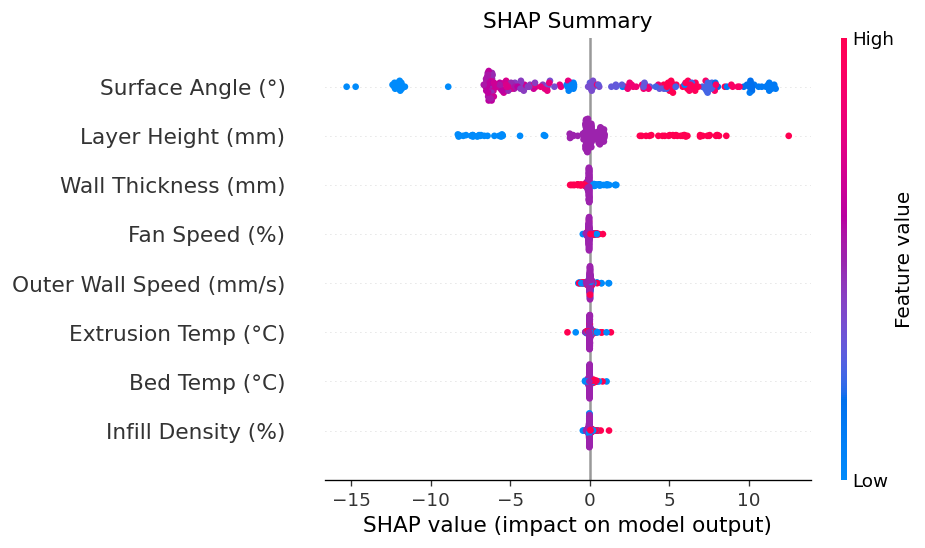

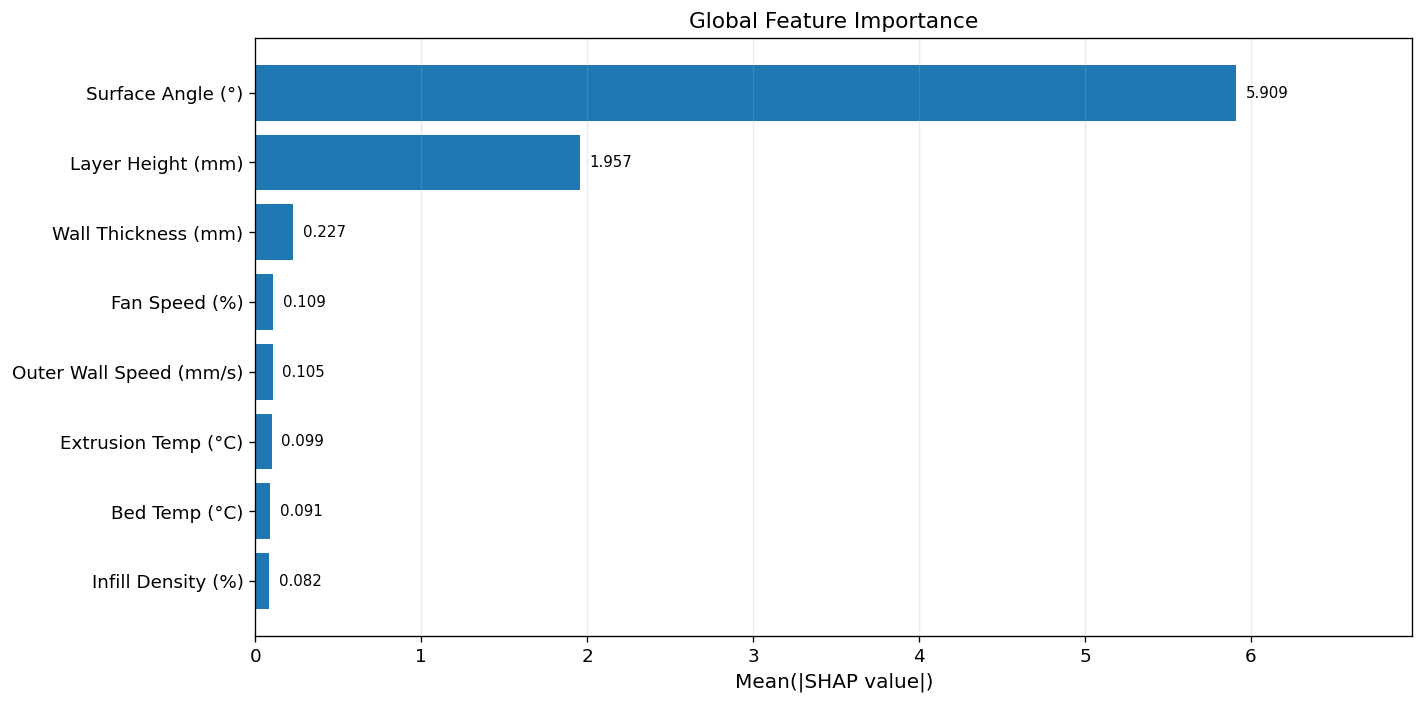

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap

# --- CONFIGURATION FLAG ---
save_to_disk = False  # Set to True if you want to save files to 'shap_outputs'
# --------------------------

required_vars = ["best_mlp_result", "best_overall_name", "scaler_x", "X_train_real", "X_test", "input_cols"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables from previous cells: {missing}\n"
        "Please run the training/selection cell first."
    )

best_model = best_mlp_result["model"]
feature_names = list(input_cols)

# Only create directory if saving is enabled
out_dir = "shap_outputs"
if save_to_disk:
    os.makedirs(out_dir, exist_ok=True)

X_train_s = scaler_x.transform(X_train_real).astype(np.float32)
X_test_s  = scaler_x.transform(X_test).astype(np.float32)

def predict_fn(x):
    return best_model.predict(x, verbose=0).reshape(-1)

rng = np.random.default_rng(42)
background_size = min(150, X_train_s.shape[0])
explain_size_test = min(350, X_test_s.shape[0])

bg_idx = rng.choice(X_train_s.shape[0], size=background_size, replace=False)
background = X_train_s[bg_idx]

test_idx = rng.choice(X_test_s.shape[0], size=explain_size_test, replace=False)
X_explain_test = X_test_s[test_idx]

masker = shap.maskers.Independent(background)
explainer = shap.Explainer(predict_fn, masker, algorithm="permutation")

num_features = X_train_s.shape[1]
max_evals = max(1200, 2 * num_features * 80)
shap_test = explainer(X_explain_test, max_evals=max_evals)
shap_test.feature_names = feature_names

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

def handle_output(fig, base_name):
    """Helper to save only if flag is True and always show."""
    plt.tight_layout()
    if save_to_disk:
        png_path = os.path.join(out_dir, f"{base_name}.png")
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        print(f"Saved: {png_path}")
    plt.show()

# ==============================================================================
# 1) SHAP Beeswarm
# ==============================================================================
fig1 = plt.figure(figsize=(9, 6))
shap.plots.beeswarm(shap_test, max_display=12, show=False)
plt.title("SHAP Summary")
handle_output(fig1, "shap_summary_beeswarm_test")

# ==============================================================================
# 2) Global Feature Importance Bar
# ==============================================================================
def plot_global_bar(expl, title, base_name, max_display=12):
    sv = expl.values
    mean_abs = np.mean(np.abs(sv), axis=0)

    order = np.argsort(mean_abs)[::-1][:max_display]
    vals = mean_abs[order][::-1]
    names = [feature_names[i] for i in order][::-1]

    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(vals))
    ax.barh(y, vals)
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel("Mean(|SHAP value|)")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.25)

    vmax = float(np.max(vals)) if len(vals) else 1.0
    ax.set_xlim(0, vmax * 1.18)

    for i, v in enumerate(vals):
        ax.text(v + (vmax * 0.01), i, f"{v:.3f}", va="center", ha="left", fontsize=9)

    handle_output(fig, base_name)

plot_global_bar(
    shap_test,
    title="Global Feature Importance",
    base_name="shap_global_importance_bar"
)